In [2]:
import pandas as pd
import numpy as np
import pandas as pd

url = "https://raw.githubusercontent.com/pavanthallapalli/student-performance-app/main/Student_Performance.csv"

df = pd.read_csv(url)
df.head()
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv("/content/Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [6]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [7]:
df.duplicated().sum()

np.int64(127)

In [8]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

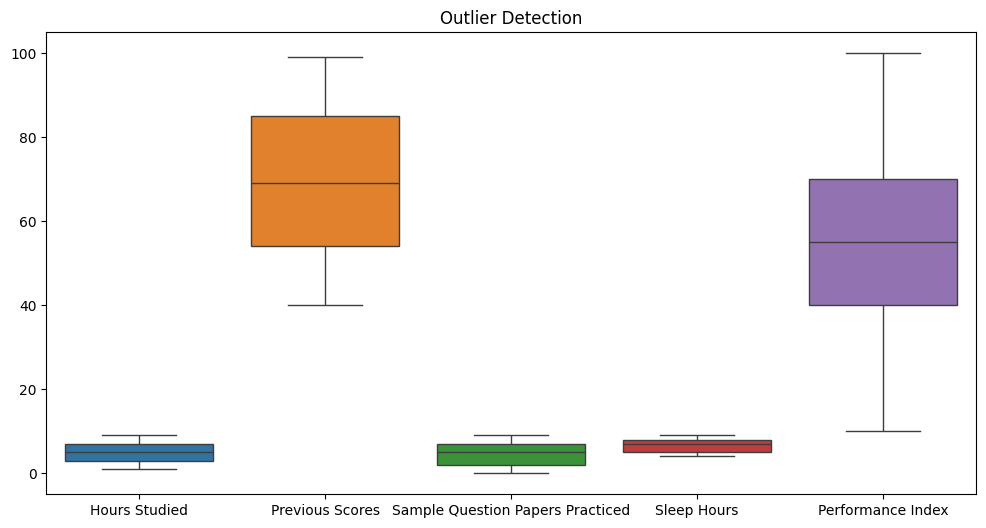

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Hours Studied', 'Previous Scores', 'Sample Question Papers Practiced',  'Sleep Hours', 'Performance Index']])
plt.title("Outlier Detection")
plt.show()

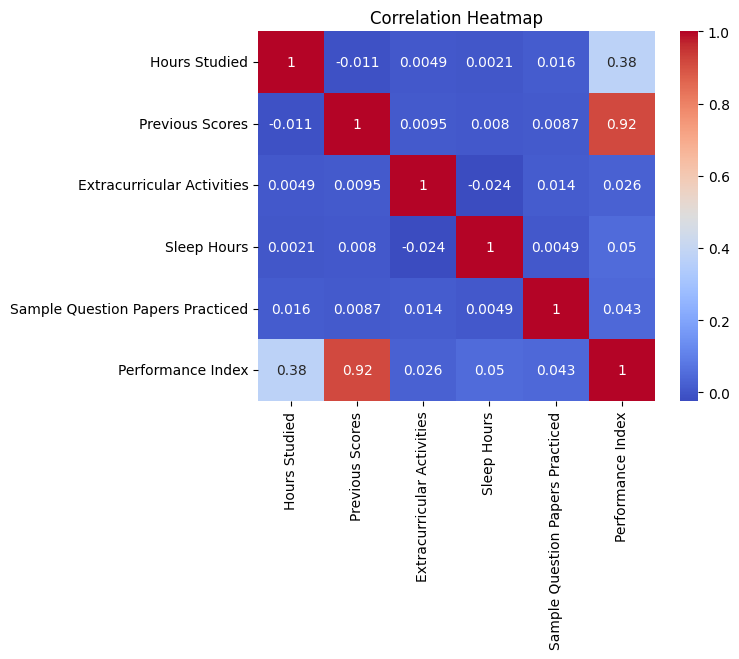

In [10]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes':1, 'No':0})
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

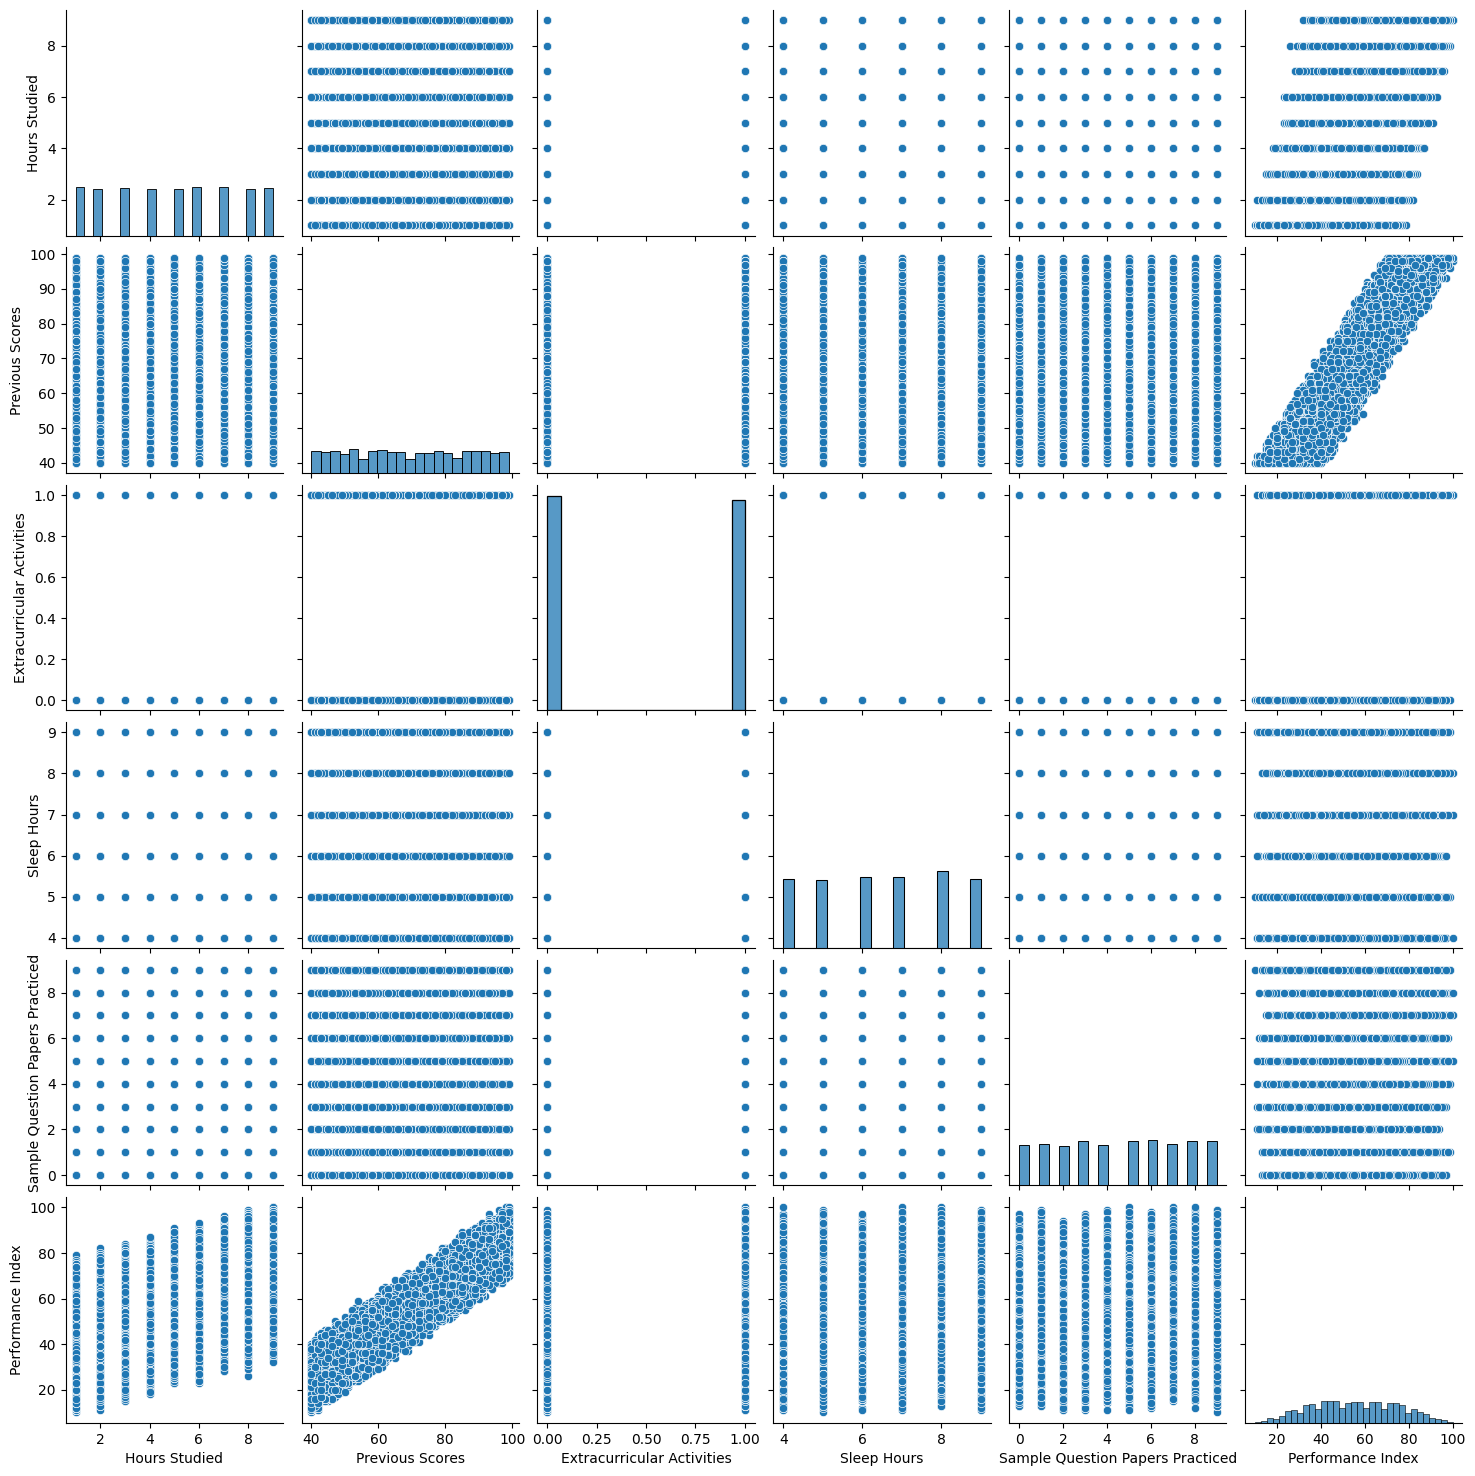

In [11]:
sns.pairplot(df)
plt.show()

In [12]:
def categorize(score):
    if score < 40:
        return "Low"
    elif score < 60:
        return "Medium"
    elif score < 80:
        return "High"
    else:
        return "Excellent"

df['Performance_Category'] = df['Performance Index'].apply(categorize)

In [13]:
print(df['Performance_Category'].value_counts())

Performance_Category
Medium       3285
High         3069
Low          2354
Excellent    1165
Name: count, dtype: int64


In [14]:
df = df.drop("Performance Index", axis=1)

In [15]:
# Target encoding
le = LabelEncoder()
df['Performance_Category'] = le.fit_transform(df['Performance_Category'])

In [16]:
X = df.drop("Performance_Category", axis=1)
y = df["Performance_Category"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9265822784810127
Confusion Matrix:
 [[238   7   0   0]
 [ 30 574   0  23]
 [  0   0 440  21]
 [  0  25  39 578]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       245
           1       0.95      0.92      0.93       627
           2       0.92      0.95      0.94       461
           3       0.93      0.90      0.91       642

    accuracy                           0.93      1975
   macro avg       0.92      0.94      0.93      1975
weighted avg       0.93      0.93      0.93      1975



In [20]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9103797468354431
Confusion Matrix:
 [[224  21   0   0]
 [ 18 576   0  33]
 [  0   0 419  42]
 [  0  25  38 579]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       245
           1       0.93      0.92      0.92       627
           2       0.92      0.91      0.91       461
           3       0.89      0.90      0.89       642

    accuracy                           0.91      1975
   macro avg       0.91      0.91      0.91      1975
weighted avg       0.91      0.91      0.91      1975



In [21]:
from sklearn.linear_model import LogisticRegression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
print("Best LR Params:", grid_lr.best_params_)

Best LR Params: {'C': 10, 'solver': 'lbfgs'}


In [22]:
from sklearn.ensemble import RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [23]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_lr, X_train, y_train, cv=5)
print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross Validation Scores: [0.92911392 0.92341772 0.9221519  0.92780241 0.92780241]
Mean CV Score: 0.9260576714953384


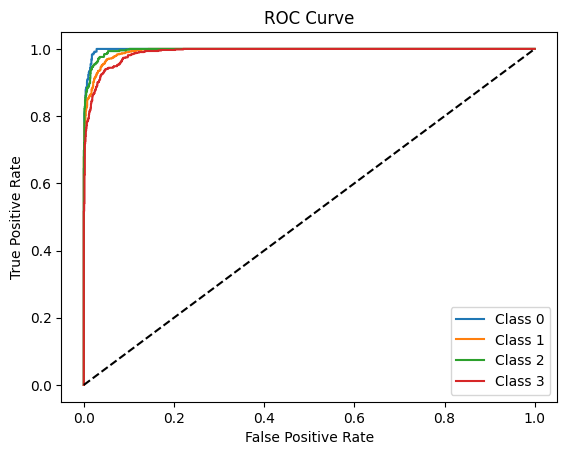

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1,2,3])

y_score = best_lr.predict_proba(X_test)

for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

                            Feature  Importance
1                   Previous Scores    0.739957
0                     Hours Studied    0.202059
4  Sample Question Papers Practiced    0.028705
3                       Sleep Hours    0.021455
2        Extracurricular Activities    0.007824


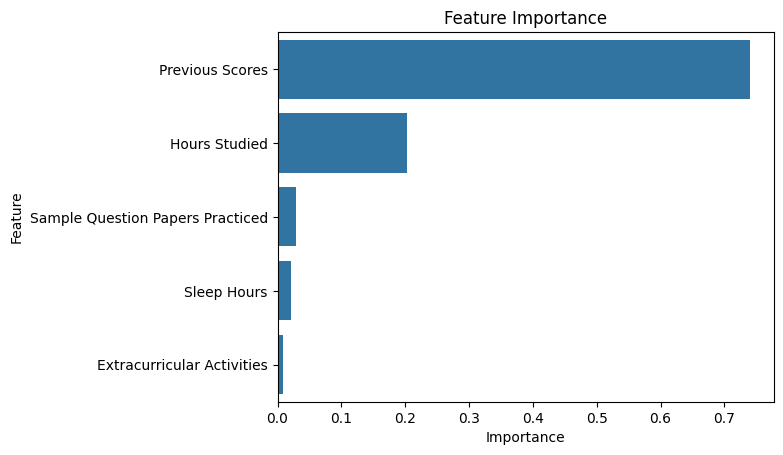

In [25]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.show()

In [26]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})
print(results)

                 Model  Accuracy
0  Logistic Regression  0.929620
1        Random Forest  0.917468


In [27]:
import pickle
pickle.dump(best_lr, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [28]:
print(le.classes_)

['Excellent' 'High' 'Low' 'Medium']


In [30]:
import pickle

model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

print("Loaded successfully")
print(type(model))
print(type(scaler))

Loaded successfully
<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.preprocessing._data.StandardScaler'>
